# 05 -- Optimisation budgetaire & What-If
## RobynMMM -- Business Scientist MCE -- Ekimetrics

**Objectif :** repondre a la question numero 1 du client :
*Comment redistribuer notre budget media pour maximiser le revenue ?*

On utilise les coefficients bayesiens pour construire une fonction de revenue,
puis on l'optimise sous contrainte de budget avec `scipy.optimize`.

---
### Plan
1. Chargement des resultats bayesiens
2. Fonction de revenue (modele MMM)
3. Optimisation sous contrainte budget
4. Comparaison : actuel vs optimal
5. Simulations what-if
6. Courbes de saturation et budget marginal utile
7. Recommandations client

## 0. Imports & chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import minimize, differential_evolution
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 11,
})

# Chargement features
FEAT_PATH = Path("../data/processed/dt_features.parquet")
df = pd.read_parquet(FEAT_PATH)
df["date"] = pd.to_datetime(df["date"])

MEDIA_COLS   = ["tv_S", "ooh_S", "print_S", "facebook_S", "search_S"]
MEDIA_LABELS = {"tv_S":"TV","ooh_S":"OOH","print_S":"Print","facebook_S":"Facebook","search_S":"Search"}
MEDIA_COLORS = {"tv_S":"#4E9AF1","ooh_S":"#F5C842","print_S":"#6BCB77","facebook_S":"#FF7043","search_S":"#9C5CF5"}
media_present = [c for c in MEDIA_COLS if c in df.columns]

Path("../outputs/figures").mkdir(parents=True, exist_ok=True)
Path("../outputs/reports").mkdir(parents=True, exist_ok=True)

# Chargement resultats bayesiens
with open("../outputs/models/bayes_model.pkl", "rb") as f:
    bayes_data = pickle.load(f)

# Chargement resultats OLS pour comparaison
with open("../outputs/models/ols_model.pkl", "rb") as f:
    ols_data = pickle.load(f)

y_mean       = bayes_data["y_mean"]
y_std        = bayes_data["y_std"]
contrib_mean = bayes_data["contrib_mean"]

print(f"[OK] Donnees chargees : {df.shape}")
print(f"[OK] Modele bayesien charge")
print(f"Revenue moyen historique : {y_mean/1e6:.2f}M EUR/semaine")
print(f"Budget media moyen total : {df[media_present].sum(axis=1).mean()/1e3:.1f}k EUR/semaine")

[OK] Donnees chargees : (208, 20)
[OK] Modele bayesien charge
Revenue moyen historique : 1.82M EUR/semaine
Budget media moyen total : 69.9k EUR/semaine


## 1. Parametres du modele MMM

On reconstruit la fonction de revenue a partir des parametres estimes.
Les coefficients bayesiens (moyennes posterieures) servent de point estimate
pour l'optimisation. L'incertitude sera representee dans les simulations what-if.

In [2]:
# Parametres adstock et saturation (memes que notebook 02)
ADSTOCK_DECAY = {
    "tv_S":0.65, "ooh_S":0.40, "print_S":0.60,
    "facebook_S":0.40, "search_S":0.20
}
HILL_ALPHA = {
    "tv_S":2.0, "ooh_S":1.5, "print_S":1.2,
    "facebook_S":2.5, "search_S":1.8
}
HILL_GAMMA = {
    "tv_S":40000, "ooh_S":80000, "print_S":8000,
    "facebook_S":5000, "search_S":10000
}

# Coefficients bayesiens (beta * y_std = contribution en EUR par unite d effet)
# On charge la trace pour calculer les moyennes
import arviz as az
trace = az.from_netcdf("../outputs/models/bayes_trace.nc")
beta_samples = trace.posterior["beta_media"].values.reshape(-1, len(media_present))
BETA_BAYES   = beta_samples.mean(axis=0) * y_std  # en EUR

print("=== Parametres du modele MMM ===")
print(f"{'Canal':<14} {'Beta (EUR)':>12} {'Adstock':>10} {'Hill alpha':>12} {'Hill gamma':>12}")
print("-" * 62)
for i, mc in enumerate(media_present):
    print(f"{MEDIA_LABELS[mc]:<14} {BETA_BAYES[i]:>12,.0f} {ADSTOCK_DECAY[mc]:>10.2f} "
          f"{HILL_ALPHA[mc]:>12.1f} {HILL_GAMMA[mc]:>12,.0f}")

=== Parametres du modele MMM ===
Canal            Beta (EUR)    Adstock   Hill alpha   Hill gamma
--------------------------------------------------------------
TV                  435,922       0.65          2.0       40,000
OOH                 137,360       0.40          1.5       80,000
Print               123,711       0.60          1.2        8,000
Facebook            267,161       0.40          2.5        5,000
Search              323,878       0.20          1.8       10,000


## 2. Fonctions core du modele MMM

In [3]:
def adstock_geometric(x, decay):
    result = np.zeros(len(x))
    result[0] = x[0]
    for t in range(1, len(x)):
        result[t] = x[t] + decay * result[t - 1]
    return result

def hill_function(x, alpha, gamma):
    x = np.maximum(x, 0)
    return x**alpha / (x**alpha + gamma**alpha)

def compute_revenue_from_spend(spend_dict, n_weeks=52, baseline_per_week=None):
    if baseline_per_week is None:
        # Baseline = intercept moyen du modele bayesien
        alpha_samples = trace.posterior["alpha"].values.flatten()
        baseline_per_week = float(alpha_samples.mean() * y_std + y_mean * 0.75)

    total_revenue = baseline_per_week * n_weeks

    for i, mc in enumerate(media_present):
        weekly_spend = spend_dict.get(mc, 0)
        spend_series = np.full(n_weeks, weekly_spend)

        # Adstock
        ads = adstock_geometric(spend_series, ADSTOCK_DECAY[mc])
        # Saturation
        sat = hill_function(ads, HILL_ALPHA[mc], HILL_GAMMA[mc])
        # Contribution
        contrib = BETA_BAYES[i] * sat.mean()
        total_revenue += contrib * n_weeks

    return total_revenue

# Budget actuel (moyenne historique par canal)
BUDGET_ACTUEL = {mc: df[mc].mean() for mc in media_present}
BUDGET_TOTAL  = sum(BUDGET_ACTUEL.values())

print("=== Budget actuel (EUR/semaine moyen) ===")
for mc in media_present:
    pct = BUDGET_ACTUEL[mc] / BUDGET_TOTAL * 100
    print(f"  {MEDIA_LABELS[mc]:<14} {BUDGET_ACTUEL[mc]:>10,.0f} EUR  ({pct:.1f}%)")
print(f"  {'TOTAL':<14} {BUDGET_TOTAL:>10,.0f} EUR")

rev_actuel = compute_revenue_from_spend(BUDGET_ACTUEL)
print(f"\nRevenue estime (actuel) : {rev_actuel/1e6:.2f}M EUR/an")

=== Budget actuel (EUR/semaine moyen) ===
  TV                 14,844 EUR  (21.3%)
  OOH                43,218 EUR  (61.9%)
  Print               3,729 EUR  (5.3%)
  Facebook            2,146 EUR  (3.1%)
  Search              5,916 EUR  (8.5%)
  TOTAL              69,851 EUR

Revenue estime (actuel) : 76.74M EUR/an


## 3. Optimisation sous contrainte de budget

### Formulation

```
Maximiser   : revenue(spend_TV, spend_OOH, spend_Print, spend_FB, spend_Search)
Sous contrainte : sum(spends) = budget_total  (meme budget total)
Bornes       : spend_k >= budget_min_k  (pas de canal a zero)
```

On utilise `scipy.optimize.minimize` avec la methode SLSQP (Sequential Least Squares Programming)
qui gere les contraintes d'egalite et les bornes.

In [4]:
def negative_revenue(spends_array):
    spend_dict = {mc: s for mc, s in zip(media_present, spends_array)}
    return -compute_revenue_from_spend(spend_dict)

# Contraintes et bornes
budget_total = BUDGET_TOTAL

# Contrainte : budget total fixe
constraints = [{"type": "eq", "fun": lambda x: x.sum() - budget_total}]

# Bornes : minimum 2% du budget par canal (eviter les zeros)
min_spend = budget_total * 0.02
max_spend = budget_total * 0.70  # max 70% sur un seul canal

bounds = [(min_spend, max_spend)] * len(media_present)

# Point de depart : allocation actuelle
x0 = np.array([BUDGET_ACTUEL[mc] for mc in media_present])

print("Optimisation en cours...")
result = minimize(
    negative_revenue,
    x0,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={"maxiter": 1000, "ftol": 1e-9},
)

BUDGET_OPTIMAL = {mc: s for mc, s in zip(media_present, result.x)}
rev_optimal    = compute_revenue_from_spend(BUDGET_OPTIMAL)
lift           = (rev_optimal - rev_actuel) / rev_actuel * 100

print(f"\nOptimisation : {'OK' if result.success else 'ATTENTION -- verifier'}")
print(f"Status : {result.message}")
print(f"\n=== Budget optimal (EUR/semaine) ===")
print(f"{'Canal':<14} {'Actuel':>12} {'Optimal':>12} {'Delta':>12} {'Delta %':>10}")
print("-" * 62)
for mc in media_present:
    act = BUDGET_ACTUEL[mc]
    opt = BUDGET_OPTIMAL[mc]
    delta = opt - act
    delta_pct = delta / act * 100
    sign = "+" if delta > 0 else ""
    print(f"{MEDIA_LABELS[mc]:<14} {act:>12,.0f} {opt:>12,.0f} {sign}{delta:>+11,.0f} {sign}{delta_pct:>+9.1f}%")

print(f"\nRevenue actuel  : {rev_actuel/1e6:.2f}M EUR/an")
print(f"Revenue optimal : {rev_optimal/1e6:.2f}M EUR/an")
print(f"Lift estime     : +{lift:.1f}%")

Optimisation en cours...

Optimisation : ATTENTION -- verifier
Status : Positive directional derivative for linesearch

=== Budget optimal (EUR/semaine) ===
Canal                Actuel      Optimal        Delta    Delta %
--------------------------------------------------------------
TV                   14,844       31,684 +    +16,840 +   +113.5%
OOH                  43,218        1,397     -41,821     -96.8%
Print                 3,729        7,440 +     +3,711 +    +99.5%
Facebook              2,146        9,300 +     +7,155 +   +333.5%
Search                5,916       20,030 +    +14,115 +   +238.6%

Revenue actuel  : 76.74M EUR/an
Revenue optimal : 98.70M EUR/an
Lift estime     : +28.6%


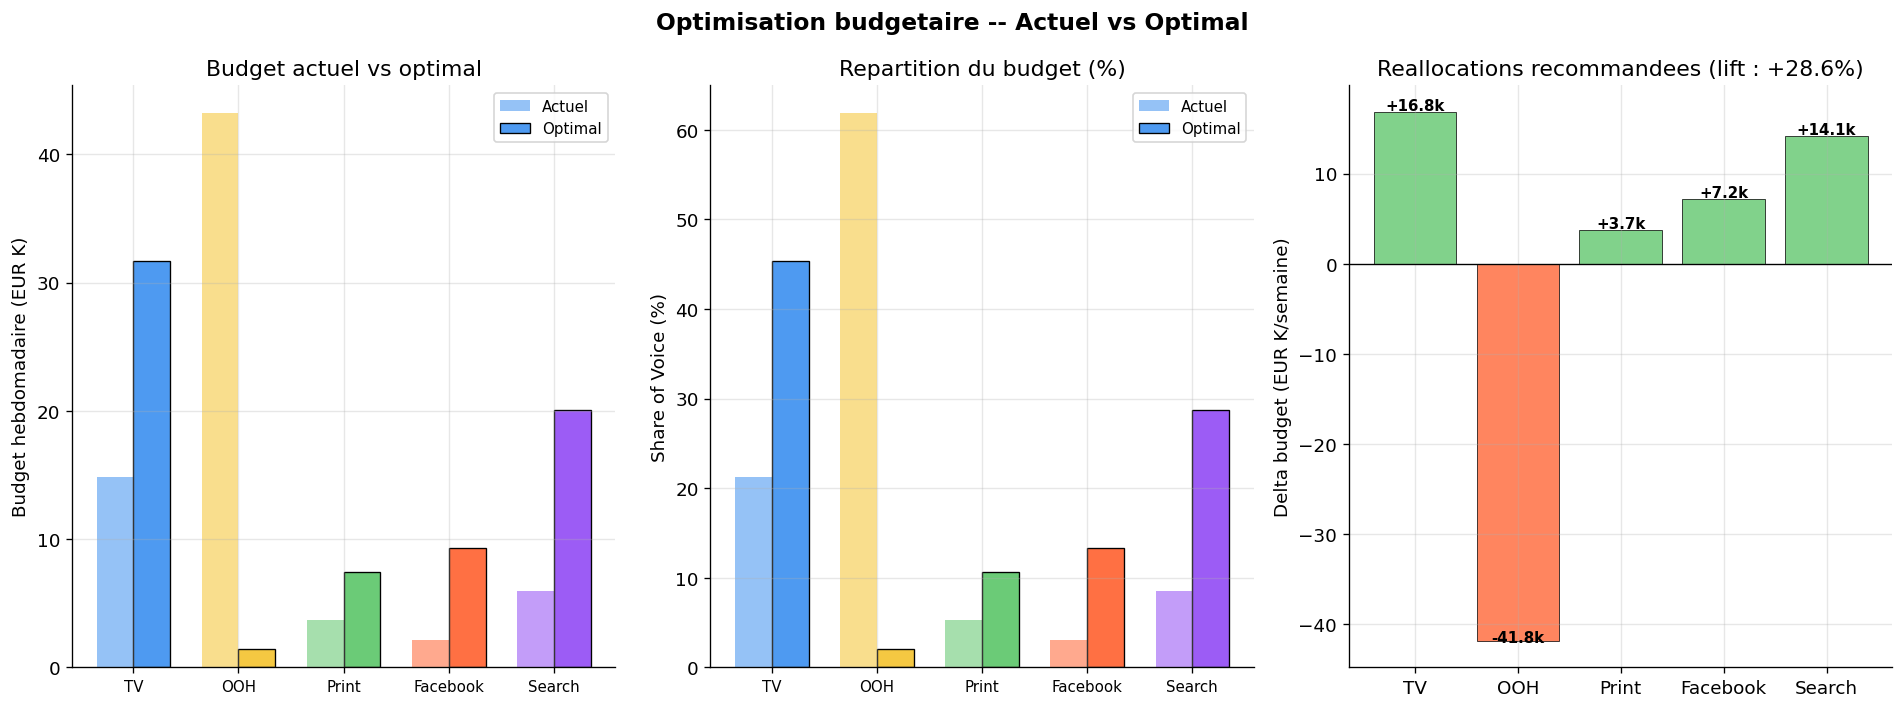

[OK] Figure sauvegardee


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Optimisation budgetaire -- Actuel vs Optimal", fontsize=14, fontweight="bold")

labels = [MEDIA_LABELS[mc] for mc in media_present]
colors = [MEDIA_COLORS[mc] for mc in media_present]
actuel_vals  = [BUDGET_ACTUEL[mc]/1000  for mc in media_present]
optimal_vals = [BUDGET_OPTIMAL[mc]/1000 for mc in media_present]

# Budget actuel vs optimal
ax = axes[0]
x = np.arange(len(media_present))
width = 0.35
ax.bar(x - width/2, actuel_vals,  width, label="Actuel",  alpha=0.6, color=colors)
ax.bar(x + width/2, optimal_vals, width, label="Optimal", alpha=1.0,
       color=colors, edgecolor="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Budget hebdomadaire (EUR K)")
ax.set_title("Budget actuel vs optimal")
ax.legend(fontsize=9)

# Share of Voice actuel vs optimal
ax2 = axes[1]
sov_actuel  = [BUDGET_ACTUEL[mc]/BUDGET_TOTAL*100  for mc in media_present]
sov_optimal = [BUDGET_OPTIMAL[mc]/BUDGET_TOTAL*100 for mc in media_present]
ax2.bar(x - width/2, sov_actuel,  width, label="Actuel",  alpha=0.6, color=colors)
ax2.bar(x + width/2, sov_optimal, width, label="Optimal", alpha=1.0,
        color=colors, edgecolor="black", linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylabel("Share of Voice (%)")
ax2.set_title("Repartition du budget (%)")
ax2.legend(fontsize=9)

# Delta budgetaire
ax3 = axes[2]
deltas = [(BUDGET_OPTIMAL[mc] - BUDGET_ACTUEL[mc])/1000 for mc in media_present]
colors_delta = ["#6BCB77" if d > 0 else "#FF7043" for d in deltas]
bars = ax3.bar(labels, deltas, color=colors_delta, alpha=0.85,
               edgecolor="black", linewidth=0.5)
ax3.axhline(y=0, color="black", linewidth=0.8)
ax3.set_ylabel("Delta budget (EUR K/semaine)")
title_ax3 = f"Reallocations recommandees (lift : +{lift:.1f}%)"
ax3.set_title(title_ax3)
for bar, val in zip(bars, deltas):
    sign = "+" if val > 0 else ""
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2 * np.sign(val),
             f"{sign}{val:.1f}k", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/figures/05_optimisation.png", bbox_inches="tight", dpi=150)
plt.show()
print("[OK] Figure sauvegardee")

## 4. Simulations what-if

### Scenarios

On simule 4 scenarios alternatifs pour montrer l'impact de differentes decisions budgetaires.
C'est le livrable qu'un client demande en reunion : *que se passe-t-il si...*

In [7]:
scenarios = {
    "Actuel": BUDGET_ACTUEL.copy(),
    "Optimal": BUDGET_OPTIMAL.copy(),
    "Coupe OOH -50%": {
        mc: (BUDGET_ACTUEL[mc] * 0.5 if mc == "ooh_S"
             else BUDGET_ACTUEL[mc] + BUDGET_ACTUEL["ooh_S"] * 0.5 / (len(media_present)-1))
        for mc in media_present
    },
    "Double Facebook": {
        mc: (BUDGET_ACTUEL[mc] * 2 if mc == "facebook_S"
             else BUDGET_ACTUEL[mc] - BUDGET_ACTUEL["facebook_S"] / (len(media_present)-1))
        for mc in media_present
    },
    "Budget +20%": {
        mc: BUDGET_ACTUEL[mc] * 1.2 for mc in media_present
    },
}

print("=== Simulations What-If ===")
print(f"{'Scenario':<22} {'Revenue/an (M)':>16} {'vs Actuel':>12} {'Budget/sem':>12}")
print("-" * 66)

scenario_results = {}
for name, budget in scenarios.items():
    rev = compute_revenue_from_spend(budget)
    vs_actuel = (rev - rev_actuel) / rev_actuel * 100
    budget_sem = sum(budget.values())
    scenario_results[name] = {
        "revenue": rev, "vs_actuel": vs_actuel,
        "budget": budget, "budget_sem": budget_sem
    }
    sign = "+" if vs_actuel > 0 else ""
    print(f"{name:<22} {rev/1e6:>16.2f} {sign}{vs_actuel:>+11.1f}% {budget_sem/1000:>10.1f}k")

=== Simulations What-If ===
Scenario                 Revenue/an (M)    vs Actuel   Budget/sem
------------------------------------------------------------------
Actuel                            76.74        +0.0%       69.9k
Optimal                           98.70 +      +28.6%       69.9k
Coupe OOH -50%                    93.19 +      +21.4%       69.9k
Double Facebook                   80.98 +       +5.5%       69.9k
Budget +20%                       82.31 +       +7.3%       83.8k


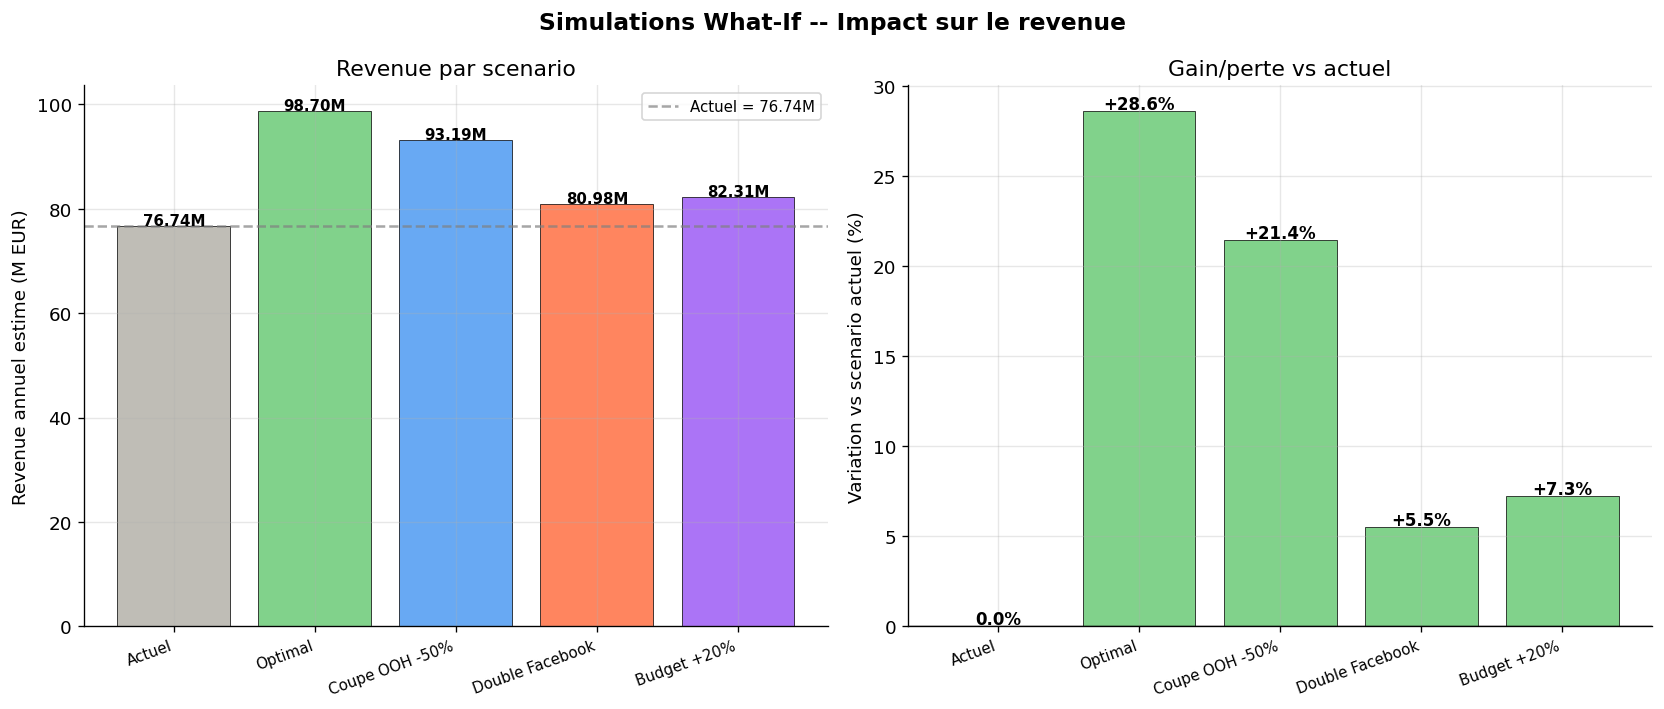

[OK] Figure sauvegardee


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Simulations What-If -- Impact sur le revenue", fontsize=14, fontweight="bold")

scenario_names = list(scenarios.keys())
revenues = [scenario_results[n]["revenue"]/1e6 for n in scenario_names]
vs_actuel = [scenario_results[n]["vs_actuel"] for n in scenario_names]
colors_sc = ["#B4B2A9", "#6BCB77", "#4E9AF1", "#FF7043", "#9C5CF5"]

# Revenue par scenario
ax = axes[0]
bars = ax.bar(scenario_names, revenues, color=colors_sc, alpha=0.85,
              edgecolor="black", linewidth=0.5)
ax.axhline(y=revenues[0], color="gray", linestyle="--", linewidth=1.5,
           alpha=0.7, label=f"Actuel = {revenues[0]:.2f}M")
ax.set_ylabel("Revenue annuel estime (M EUR)")
ax.set_title("Revenue par scenario")
ax.legend(fontsize=9)
for bar, val in zip(bars, revenues):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.2f}M", ha="center", fontsize=9, fontweight="bold")
ax.set_xticklabels(scenario_names, rotation=20, ha="right", fontsize=9)

# Delta vs actuel
ax2 = axes[1]
colors_delta = ["#B4B2A9"] + ["#6BCB77" if v > 0 else "#FF7043" for v in vs_actuel[1:]]
bars2 = ax2.bar(scenario_names, vs_actuel, color=colors_delta, alpha=0.85,
                edgecolor="black", linewidth=0.5)
ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.set_ylabel("Variation vs scenario actuel (%)")
ax2.set_title("Gain/perte vs actuel")
ax2.set_xticklabels(scenario_names, rotation=20, ha="right", fontsize=9)
for bar, val in zip(bars2, vs_actuel):
    sign = "+" if val > 0 else ""
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1 * np.sign(val) if val != 0 else 0.1,
             f"{sign}{val:.1f}%", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/figures/05_whatif.png", bbox_inches="tight", dpi=150)
plt.show()
print("[OK] Figure sauvegardee")

## 5. Courbes de saturation et budget marginal utile

Pour chaque canal, on montre le revenue incremental par euro investi en fonction du budget.
Cela permet d'identifier le **point de rendement decroissant** -- au-dela duquel investir davantage est inefficace.

=== Budget optimal par canal (point de saturation) ===
Canal            Budget actuel   Point 80% sat.   Point 95% sat.
---------------------------------------------------------------
TV                      14,844           25,418           41,677
OOH                     43,218           41,677           51,956
Print                    3,729            9,345           25,418
Facebook                 2,146            5,420           10,092
Search                   5,916           16,073           31,772


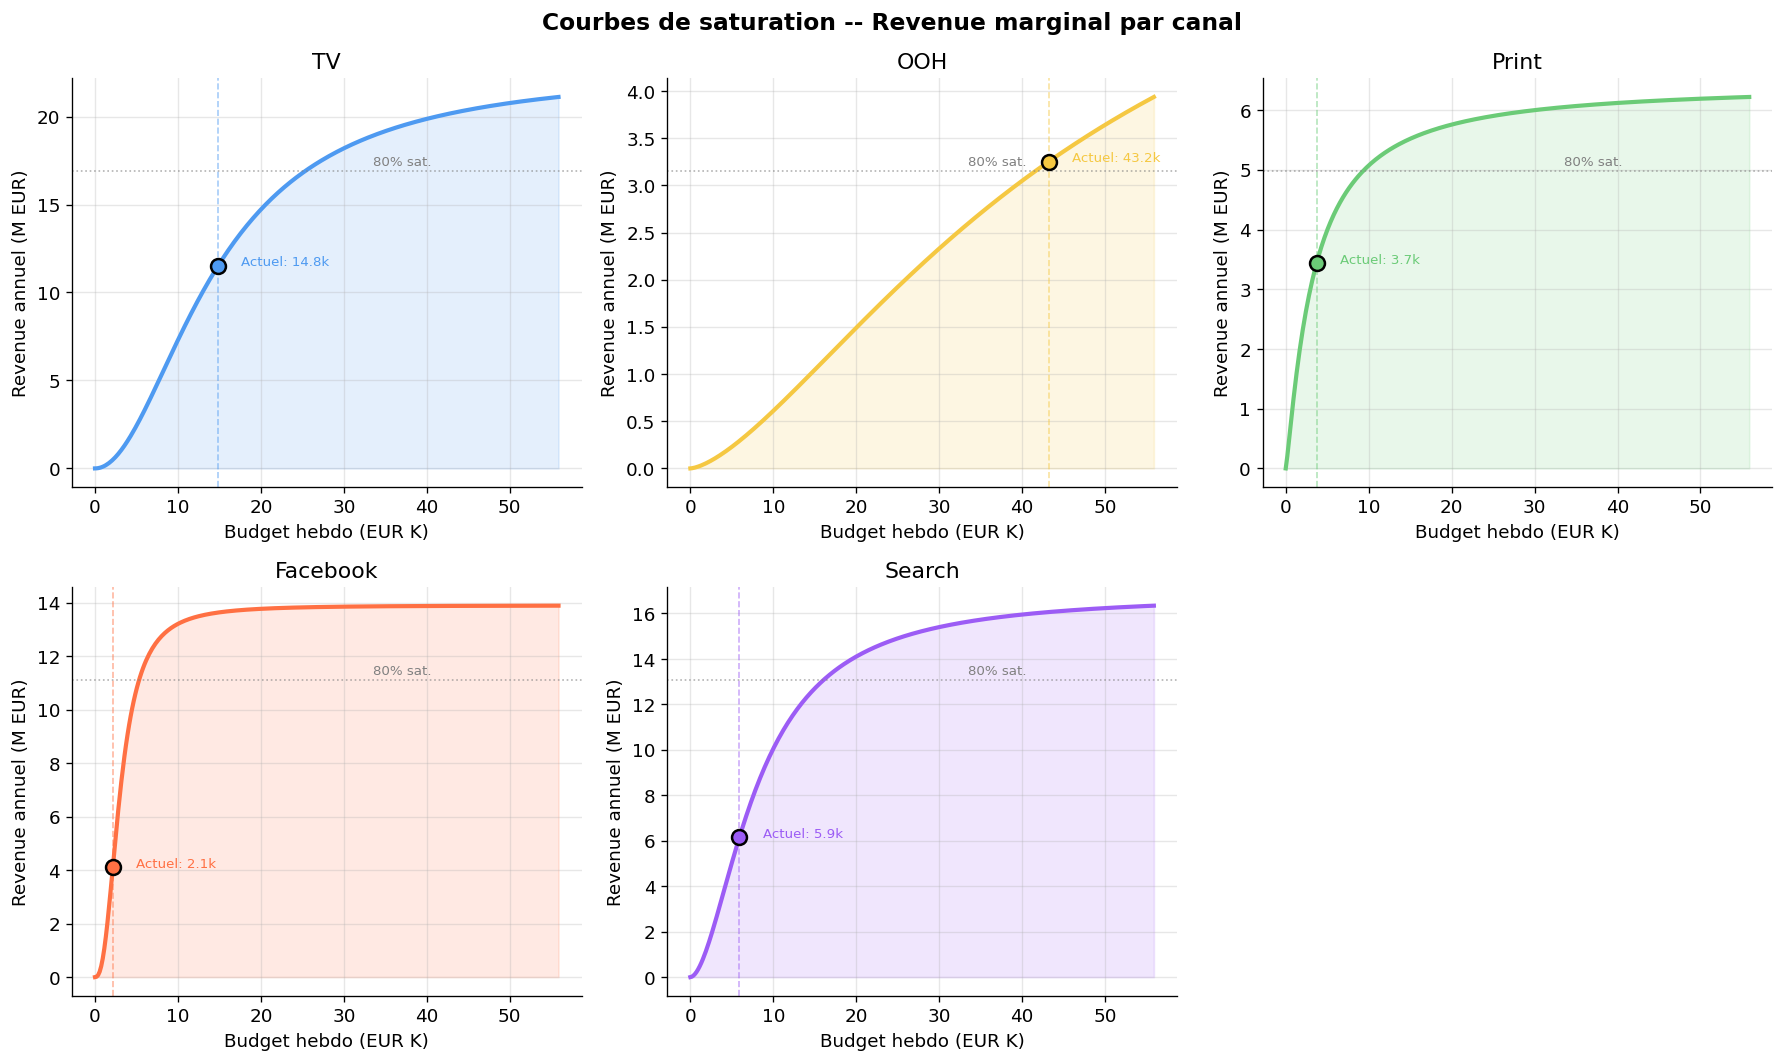

[OK] Figure sauvegardee


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Courbes de saturation -- Revenue marginal par canal",
             fontsize=14, fontweight="bold")
axes_flat = axes.flatten()

print("=== Budget optimal par canal (point de saturation) ===")
print(f"{'Canal':<14} {'Budget actuel':>15} {'Point 80% sat.':>16} {'Point 95% sat.':>16}")
print("-" * 63)

for i, mc in enumerate(media_present):
    ax = axes_flat[i]
    color = MEDIA_COLORS[mc]
    label = MEDIA_LABELS[mc]

    # Courbe revenue marginal
    budget_range = np.linspace(0, BUDGET_TOTAL * 0.8, 300)
    revenues_marginal = []
    for spend in budget_range:
        spend_series = np.full(52, spend)
        ads = adstock_geometric(spend_series, ADSTOCK_DECAY[mc])
        sat = hill_function(ads, HILL_ALPHA[mc], HILL_GAMMA[mc])
        rev_contrib = BETA_BAYES[i] * sat.mean() * 52
        revenues_marginal.append(rev_contrib)

    revenues_marginal = np.array(revenues_marginal)
    rev_max = revenues_marginal[-1]

    # Points de saturation
    idx_80 = np.argmax(revenues_marginal >= 0.80 * rev_max) if rev_max > 0 else 0
    idx_95 = np.argmax(revenues_marginal >= 0.95 * rev_max) if rev_max > 0 else 0
    budget_80 = budget_range[idx_80] if idx_80 > 0 else budget_range[-1]
    budget_95 = budget_range[idx_95] if idx_95 > 0 else budget_range[-1]

    print(f"{label:<14} {BUDGET_ACTUEL[mc]:>15,.0f} {budget_80:>16,.0f} {budget_95:>16,.0f}")

    ax.plot(budget_range/1000, revenues_marginal/1e6, color=color, linewidth=2.5)
    ax.fill_between(budget_range/1000, revenues_marginal/1e6, alpha=0.15, color=color)

    # Marquer budget actuel
    spend_act = BUDGET_ACTUEL[mc]
    spend_act_arr = np.full(52, spend_act)
    ads_act = adstock_geometric(spend_act_arr, ADSTOCK_DECAY[mc])
    sat_act = hill_function(ads_act, HILL_ALPHA[mc], HILL_GAMMA[mc])
    rev_act_pt = BETA_BAYES[i] * sat_act.mean() * 52
    ax.scatter([spend_act/1000], [rev_act_pt/1e6], s=80, color=color,
               zorder=5, edgecolors="black", linewidth=1.5)
    ax.axvline(x=spend_act/1000, color=color, linestyle="--", alpha=0.5, linewidth=1)

    # Marquer point 80%
    ax.axhline(y=0.80*rev_max/1e6, color="gray", linestyle=":", alpha=0.6, linewidth=1)
    ax.annotate("80% sat.", xy=(budget_range[-1]*0.6/1000, 0.80*rev_max/1e6*1.02),
                fontsize=8, color="gray")

    ax.set_title(label)
    ax.set_xlabel("Budget hebdo (EUR K)")
    ax.set_ylabel("Revenue annuel (M EUR)")

    annot_txt = f"Actuel: {spend_act/1000:.1f}k"
    annot_x   = spend_act/1000 + budget_range[-1]*0.05/1000
    ax.annotate(annot_txt,
                xy=(spend_act/1000, rev_act_pt/1e6),
                xytext=(annot_x, rev_act_pt/1e6),
                fontsize=8, color=color)

axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/figures/05_saturation_curves.png", bbox_inches="tight", dpi=150)
plt.show()
print("[OK] Figure sauvegardee")

## 6. Rapport client -- Recommandations finales

In [11]:
print("=" * 70)
print("  RECOMMANDATIONS MEDIA -- RobynMMM")
print("  Marque FMCG Anonymisee -- Budget annuel")
print("=" * 70)
print()
print("SITUATION ACTUELLE")
print(f"  Budget total  : {BUDGET_TOTAL * 52 / 1e6:.1f}M EUR/an")
print(f"  Revenue estime: {rev_actuel / 1e6:.1f}M EUR/an")
print(f"  ROAS global   : {rev_actuel / (BUDGET_TOTAL * 52):.1f}x")
print()
print("DIAGNOSTIC MEDIA")

roas_dict = {}
for i, mc in enumerate(media_present):
    spend = BUDGET_ACTUEL[mc]
    contrib = contrib_mean[mc].mean()
    roas = contrib / spend if spend > 0 else 0
    roas_dict[mc] = roas

for mc in sorted(media_present, key=lambda x: roas_dict[x], reverse=True):
    pct_budget = BUDGET_ACTUEL[mc] / BUDGET_TOTAL * 100
    status = "SURPERF" if roas_dict[mc] > 10 else "OK" if roas_dict[mc] > 5 else "SOUSPERF"
    print(f"  {MEDIA_LABELS[mc]:<14} {pct_budget:.0f}% budget  ROAS~{roas_dict[mc]:.0f}x  [{status}]")

print()
print("RECOMMANDATIONS (meme budget total)")
for mc in media_present:
    delta = BUDGET_OPTIMAL[mc] - BUDGET_ACTUEL[mc]
    delta_pct = delta / BUDGET_ACTUEL[mc] * 100
    if abs(delta_pct) > 5:
        action = "AUGMENTER" if delta > 0 else "REDUIRE  "
        print(f"  {action} {MEDIA_LABELS[mc]:<12} {delta_pct:+.0f}%  ({delta/1000:+.1f}k EUR/sem)")

print()
print(f"IMPACT ATTENDU")
print(f"  Revenue optimal : {rev_optimal/1e6:.1f}M EUR/an")
print(f"  Lift vs actuel  : +{lift:.1f}%")
print(f"  Revenue additionnel : +{(rev_optimal-rev_actuel)/1e6:.1f}M EUR/an")
print()
print("SCENARIO PRIORITAIRE : Couper OOH de 50% -> Reinvestir en Facebook et Search")
rev_sc = scenario_results["Coupe OOH -50%"]["revenue"]
lift_sc = scenario_results["Coupe OOH -50%"]["vs_actuel"]
print(f"  Revenue estime  : {rev_sc/1e6:.1f}M EUR/an  (+{lift_sc:.1f}% vs actuel)")
print("=" * 70)

# Export
report = pd.DataFrame({
    "canal": [MEDIA_LABELS[mc] for mc in media_present],
    "budget_actuel_EUR_sem": [BUDGET_ACTUEL[mc] for mc in media_present],
    "budget_optimal_EUR_sem": [BUDGET_OPTIMAL[mc] for mc in media_present],
    "delta_EUR_sem": [BUDGET_OPTIMAL[mc]-BUDGET_ACTUEL[mc] for mc in media_present],
    "delta_pct": [(BUDGET_OPTIMAL[mc]-BUDGET_ACTUEL[mc])/BUDGET_ACTUEL[mc]*100 for mc in media_present],
    "roas_estime": [roas_dict[mc] for mc in media_present],
})
report.to_csv("../outputs/reports/recommandations_budget.csv", index=False)
print("[OK] Rapport sauvegarde : ../outputs/reports/recommandations_budget.csv")

  RECOMMANDATIONS MEDIA -- RobynMMM
  Marque FMCG Anonymisee -- Budget annuel

SITUATION ACTUELLE
  Budget total  : 3.6M EUR/an
  Revenue estime: 76.7M EUR/an
  ROAS global   : 21.1x

DIAGNOSTIC MEDIA
  Facebook       3% budget  ROAS~36x  [SURPERF]
  Search         8% budget  ROAS~18x  [SURPERF]
  Print          5% budget  ROAS~15x  [SURPERF]
  TV             21% budget  ROAS~12x  [SURPERF]
  OOH            62% budget  ROAS~1x  [SOUSPERF]

RECOMMANDATIONS (meme budget total)
  AUGMENTER TV           +113%  (+16.8k EUR/sem)
  REDUIRE   OOH          -97%  (-41.8k EUR/sem)
  AUGMENTER Print        +100%  (+3.7k EUR/sem)
  AUGMENTER Facebook     +333%  (+7.2k EUR/sem)
  AUGMENTER Search       +239%  (+14.1k EUR/sem)

IMPACT ATTENDU
  Revenue optimal : 98.7M EUR/an
  Lift vs actuel  : +28.6%
  Revenue additionnel : +22.0M EUR/an

SCENARIO PRIORITAIRE : Couper OOH de 50% -> Reinvestir en Facebook et Search
  Revenue estime  : 93.2M EUR/an  (+21.4% vs actuel)
[OK] Rapport sauvegarde : ../outp